In [1]:
import scvi
import numpy as np
import scanpy as sc

from scContextVI import scContextVIModel
from sklearn.metrics import silhouette_score

scvi.settings.seed = 42

Seed set to 42


In [2]:
adata = sc.read("./data/simulated_data.h5ad")

In [3]:
condition_key = "condition"
group_key = 'cell_type'
control_key='control'

conditions = ['control', 'treatment_1', 'treatment_2']
group_indices_list = [np.where(adata.obs[condition_key]==group)[0] for group in conditions]

scContextVIModel.setup_anndata(adata, 
                              condition_key=condition_key)

condition2int = adata.obs.groupby(condition_key, 
                                  observed=False)['_scvi_condition'].first().to_dict()

lr = 1e-3
max_epochs = 300
batch_size = 64
n_latent = 10
norm_weight = 0.5
mmd_weight = 10

In [4]:
model = scContextVIModel(
    adata,
    condition2int=condition2int,
    control=control_key,
    n_background_latent=n_latent,
    n_te_latent=n_latent,
    n_layers=2,
    n_hidden=128,
    use_mmd=True,
    mmd_weight=mmd_weight,
    norm_weight=norm_weight,
)

In [5]:
model.train(
    group_indices_list,
    max_epochs=max_epochs,
    accelerator="gpu",
    devices=[2],
    train_size=0.9,
    batch_size=batch_size,
    early_stopping=True,
    datasplitter_kwargs={"num_workers": 4},
    plan_kwargs={"lr": lr},
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 571.969. Signaling Trainer to stop.


In [6]:
adata.obsm['latent_bg'], adata.obsm['latent_t'] = model.get_latent_representation()
adata_tm1 = adata[adata.obs[condition_key] == 'treatment_1'].copy()
adata_tm1.obs['p_label'] = (adata_tm1.obs['cell_type'] == 'CD4 Naive T').astype(int)

adata_tm2 = adata[adata.obs[condition_key] == 'treatment_2'].copy()
adata_tm2.obs['p_label'] = (adata_tm2.obs['cell_type'] == 'B').astype(int)

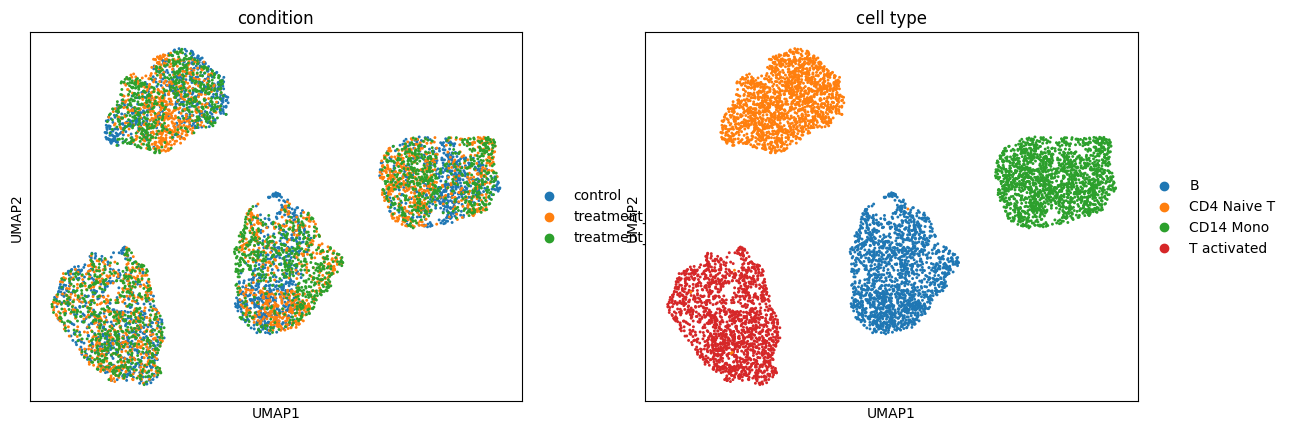

In [7]:
sc.pp.neighbors(adata, use_rep='latent_bg')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[condition_key, group_key], title=['condition', 'cell type'])

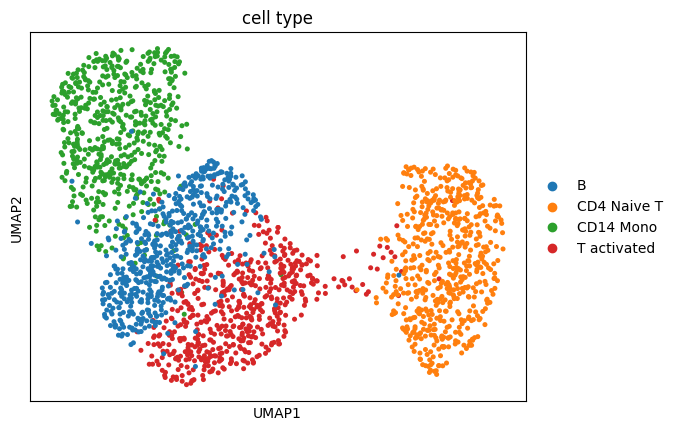

In [8]:
sc.pp.neighbors(adata_tm1, use_rep='latent_t')
sc.tl.umap(adata_tm1)
sc.pl.umap(adata_tm1, color=[group_key], title=['cell type'])

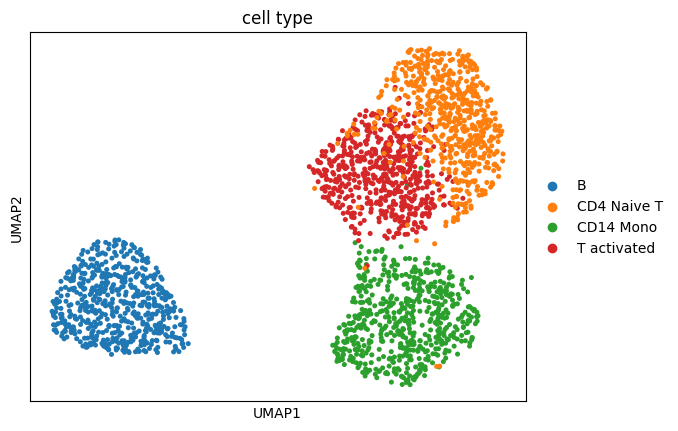

In [9]:
sc.pp.neighbors(adata_tm2, use_rep='latent_t')
sc.tl.umap(adata_tm2)
sc.pl.umap(adata_tm2, color=[group_key], title=['cell type'])

In [10]:
ASW_t1 = silhouette_score(adata_tm1.obsm['latent_t'], 
                          adata_tm1.obs["p_label"], 
                          metric="euclidean")

ASW_t2 = silhouette_score(adata_tm2.obsm['latent_t'], 
                          adata_tm2.obs["p_label"],
                            metric="euclidean")

print("ASW_TE_treatement1", ASW_t1)
print("ASW_TE_treatement2", ASW_t2)

ASW_TE_treatement1 0.560718834400177
ASW_TE_treatement2 0.5946672558784485
